In [ ]:
import time
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import numpy as np
import cv2

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms
import torchvision.models as models

import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.autograd import Function

from tqdm.notebook import tqdm

from sklearn.metrics import accuracy_score
import PIL
import matplotlib.pyplot as plt
import seaborn as sns

import time
from collections import OrderedDict

import platform
import psutil

import random
import glob
from tqdm import tqdm

from PIL import Image
from torchvision import transforms
from PIL import ImageOps

from tabulate import tabulate
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

seed = 1
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rm1000/grape-disease-dataset-original
License(s): CC0-1.0
 83% 126M/151M [00:00<00:00, 1.32GB/s]
100% 151M/151M [00:00<00:00, 1.23GB/s]
'Original Data'
test  train
'Black Rot'   ESCA   Healthy  'Leaf Blight'
Classes found: ['Black Rot', 'ESCA', 'Healthy', 'Leaf Blight']


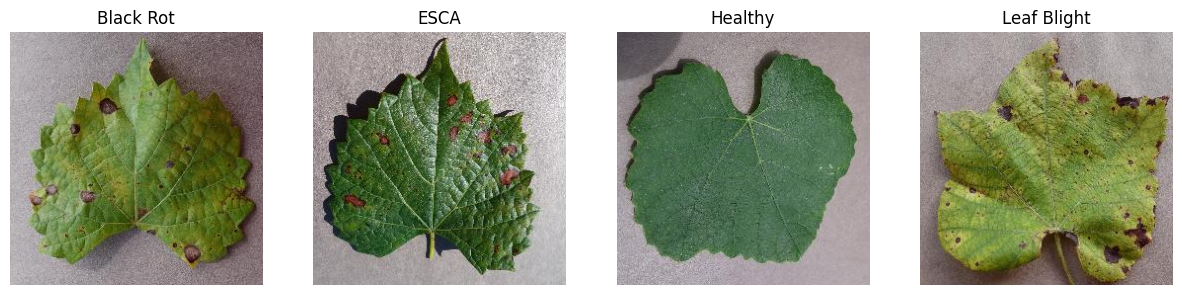

In [ ]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rm1000/grape-disease-dataset-original
!unzip -q grape-disease-dataset-original.zip -d dataset
!ls dataset
!ls /content/dataset/Original\ Data
!ls /content/dataset/Original\ Data/train

data_dir = '/content/dataset/Original Data/train'
classes = os.listdir(data_dir)
print('Classes found:', classes)

plt.figure(figsize=(15, 5))
for i, cls in enumerate(classes):
    img_path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img_rgb)
    plt.title(cls)
    plt.axis('off')
plt.show()

Training Dataset:
Total images: 7222
Images per class: {'Black Rot': 1888, 'ESCA': 1920, 'Healthy': 1692, 'Leaf Blight': 1722}

Test Dataset:
Total images: 1805
Images per class: {'Black Rot': 472, 'ESCA': 480, 'Healthy': 423, 'Leaf Blight': 430}


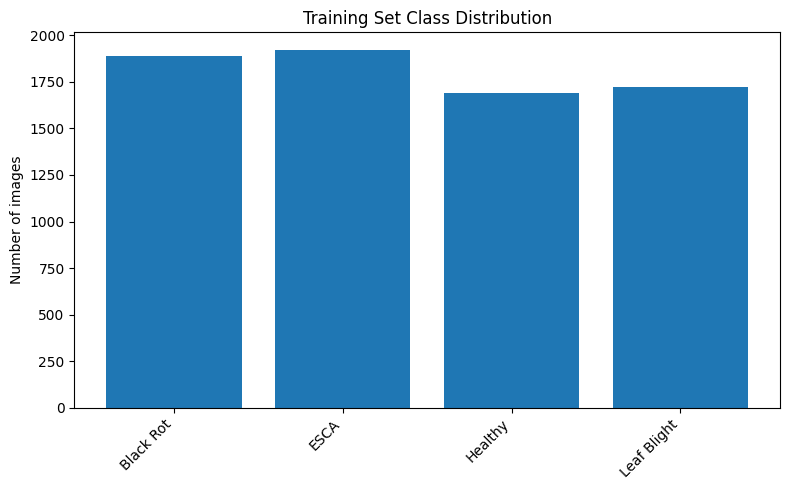

In [ ]:
train_dir = '/content/dataset/Original Data/train'
test_dir = '/content/dataset/Original Data/test'

def count_images(directory):
    total_images = 0
    class_counts = {}
    classes = os.listdir(directory)
    for cls in classes:
        class_path = os.path.join(directory, cls)
        if os.path.isdir(class_path):
            num_images = len([f for f in os.listdir(class_path) if f.endswith(('.JPG', '.JPEG', '.PNG'))])
            class_counts[cls] = num_images
            total_images += num_images
    return total_images, class_counts

train_total, train_class_counts = count_images(train_dir)
test_total, test_class_counts = count_images(test_dir)

print('Training Dataset:')
print(f'Total images: {train_total}')
print('Images per class:', train_class_counts)
print('\nTest Dataset:')
print(f'Total images: {test_total}')
print('Images per class:', test_class_counts)

classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
counts = []
for cls in classes:
    cls_dir = os.path.join(train_dir, cls)
    imgs = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]
    counts.append(len(imgs))

plt.figure(figsize=(8, 5))
plt.bar(classes, counts)
plt.title('Training Set Class Distribution')
plt.ylabel('Number of images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
train_dir = '/content/dataset/Original Data/train'
test_dir = '/content/dataset/Original Data/test'

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

full_dataset = datasets.ImageFolder(train_dir)
targets = full_dataset.targets

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

train_dataset = Subset(datasets.ImageFolder(train_dir, transform=train_transforms), train_idx)
val_dataset = Subset(datasets.ImageFolder(train_dir, transform=val_test_transforms), val_idx)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

batch_size = 8
num_workers = 2

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print('Class distribution in train split:', np.bincount(np.array(full_dataset.targets)[train_idx]))
print('Class distribution in val split:', np.bincount(np.array(full_dataset.targets)[val_idx]))

Train samples: 6499
Val samples: 723
Test samples: 1805
Class distribution in train split: [1699 1728 1523 1549]
Class distribution in val split: [189 192 169 173]


In [ ]:
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, ratio=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_planes, in_planes // ratio, bias=False),
            nn.ReLU(),
            nn.Linear(in_planes // ratio, in_planes, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x).squeeze(-1).squeeze(-1))
        max_out = self.fc(self.max_pool(x).squeeze(-1).squeeze(-1))
        out = avg_out + max_out
        return self.sigmoid(out).unsqueeze(-1).unsqueeze(-1)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.conv(out)
        return self.sigmoid(out)

class CBAM(nn.Module):
    def __init__(self, in_planes, ratio=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_planes, ratio)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

class CustomMaxPool2d(nn.Module):
    def __init__(self, kernel_size=2, stride=None, padding=0):
        super().__init__()
        self.kernel_size = kernel_size
        self.stride = stride or kernel_size
        self.padding = padding

    def forward(self, x):
        if self.padding > 0:
            x = nn.functional.pad(x, (self.padding,)*4)
        x_unf = x.unfold(2, self.kernel_size, self.stride).unfold(3, self.kernel_size, self.stride)
        N, C, outH, outW, k, _ = x_unf.shape
        x_unf = x_unf.contiguous().view(N, C, outH, outW, k * k)
        out, _ = x_unf.max(dim=-1)
        return out

class CustomCNNWithCustomPool(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomCNNWithCustomPool, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            CustomMaxPool2d(kernel_size=2, stride=2),
            CBAM(32),
            nn.Dropout(0.10),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            CustomMaxPool2d(kernel_size=2, stride=2),
            CBAM(64),
            nn.Dropout(0.10),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            CustomMaxPool2d(kernel_size=2, stride=2),
            CBAM(128),
            nn.Dropout(0.20),

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            CustomMaxPool2d(kernel_size=2, stride=2),
            CBAM(256),
            nn.Dropout(0.20),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveMaxPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        # Register hooks for Grad-CAM
        self.features[21].register_forward_hook(self._save_features_hook)
        self.features[21].register_backward_hook(self._save_gradients_hook)
        self.features_out = None
        self.gradients = None

    def _save_features_hook(self, module, input, output):
        self.features_out = output.detach()

    def _save_gradients_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0].detach()

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.model.eval()

    def generate_heatmap(self, input_image, class_idx=None):
        self.model.zero_grad()
        output = self.model(input_image)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)

        gradients = self.model.gradients
        features = self.model.features_out

        weights = torch.mean(gradients, dim=[2, 3], keepdim=True)
        heatmap = torch.sum(weights * features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap = heatmap / (torch.max(heatmap) + 1e-10)
        return heatmap.cpu().numpy(), class_idx

def visualize_gradcam(model, dataloader, classes, num_classes=4, device='cuda'):
    model.eval()
    gradcam = GradCAM(model, target_layer=model.features[21])
    selected_images = []
    selected_labels = []
    seen_classes = set()

    # Collect one image per class
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        for i in range(images.size(0)):
            label = labels[i].item()
            if label not in seen_classes:
                seen_classes.add(label)
                selected_images.append(images[i])
                selected_labels.append(label)
            if len(seen_classes) == num_classes:
                break
        if len(seen_classes) == num_classes:
            break

    # Visualize one image per class
    plt.figure(figsize=(15, 5 * num_classes))
    for idx, (img, true_label) in enumerate(zip(selected_images, selected_labels)):
        img = img.unsqueeze(0)
        heatmap, pred_class = gradcam.generate_heatmap(img)

        # Denormalize image for visualization
        img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img_np = std * img_np + mean
        img_np = np.clip(img_np, 0, 1)

        # Resize heatmap to match image size
        heatmap = cv2.resize(heatmap, (img_np.shape[1], img_np.shape[0]))
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        superimposed_img = heatmap * 0.4 + img_np * 255 * 0.6
        superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)

        # Plot original, heatmap, and overlay
        plt.subplot(num_classes, 3, idx * 3 + 1)
        plt.imshow(img_np)
        plt.title(f'Original (True: {classes[true_label]}, Pred: {classes[pred_class]})')
        plt.axis('off')

        plt.subplot(num_classes, 3, idx * 3 + 2)
        plt.imshow(heatmap)
        plt.title('Grad-CAM Heatmap')
        plt.axis('off')

        plt.subplot(num_classes, 3, idx * 3 + 3)
        plt.imshow(superimposed_img)
        plt.title('Overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Epoch 01/15 | Train: loss=0.7811, acc=0.6693 | Val: loss=0.2753, acc=0.9350
Epoch 02/15 | Train: loss=0.3726, acc=0.8598 | Val: loss=0.1074, acc=0.9668
Epoch 03/15 | Train: loss=0.2584, acc=0.9043 | Val: loss=0.0549, acc=0.9876
Epoch 04/15 | Train: loss=0.2218, acc=0.9178 | Val: loss=0.1216, acc=0.9530
Epoch 05/15 | Train: loss=0.1996, acc=0.9224 | Val: loss=0.0765, acc=0.9710
Epoch 06/15 | Train: loss=0.1799, acc=0.9314 | Val: loss=0.1062, acc=0.9599
Epoch 07/15 | Train: loss=0.1493, acc=0.9438 | Val: loss=0.0219, acc=0.9931
Epoch 08/15 | Train: loss=0.1331, acc=0.9514 | Val: loss=0.0179, acc=0.9959
Epoch 09/15 | Train: loss=0.1420, acc=0.9466 | Val: loss=0.0252, acc=0.9931
Epoch 10/15 | Train: loss=0.1162, acc=0.9565 | Val: loss=0.0142, acc=1.0000
Epoch 11/15 | Train: loss=0.1247, acc=0.9548 | Val: loss=0.0106, acc=1.0000
Epoch 12/15 | Train: loss=0.1018, acc=0.9623 | Val: loss=0.0451, acc=0.9834
Epoch 13/15 | Train: loss=0.1048, acc=0.9605 | Val: loss=0.0243, acc=0.9945
Epoch 14/15 

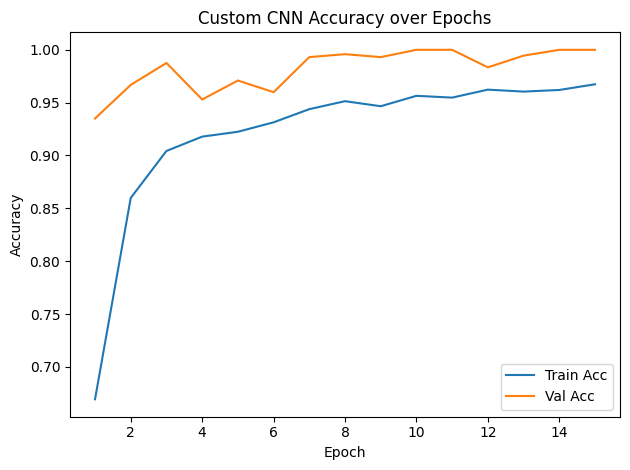

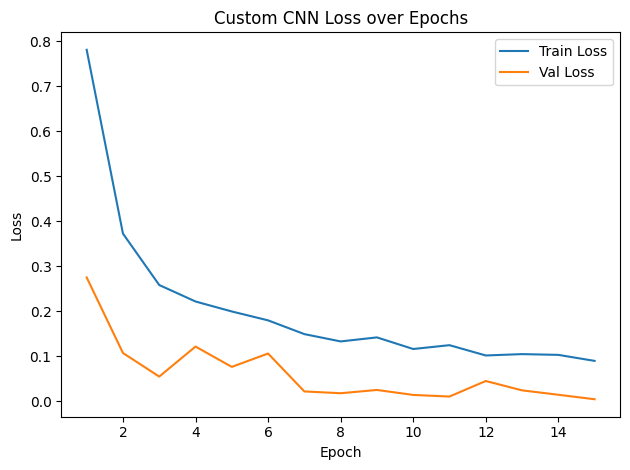

Test Accuracy: 0.9989
Confusion Matrix:
 [[472   0   0   0]
 [  2 478   0   0]
 [  0   0 423   0]
 [  0   0   0 430]]

Classification Report:
              precision    recall  f1-score   support

   Black Rot       1.00      1.00      1.00       472
        ESCA       1.00      1.00      1.00       480
     Healthy       1.00      1.00      1.00       423
 Leaf Blight       1.00      1.00      1.00       430

    accuracy                           1.00      1805
   macro avg       1.00      1.00      1.00      1805
weighted avg       1.00      1.00      1.00      1805



/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


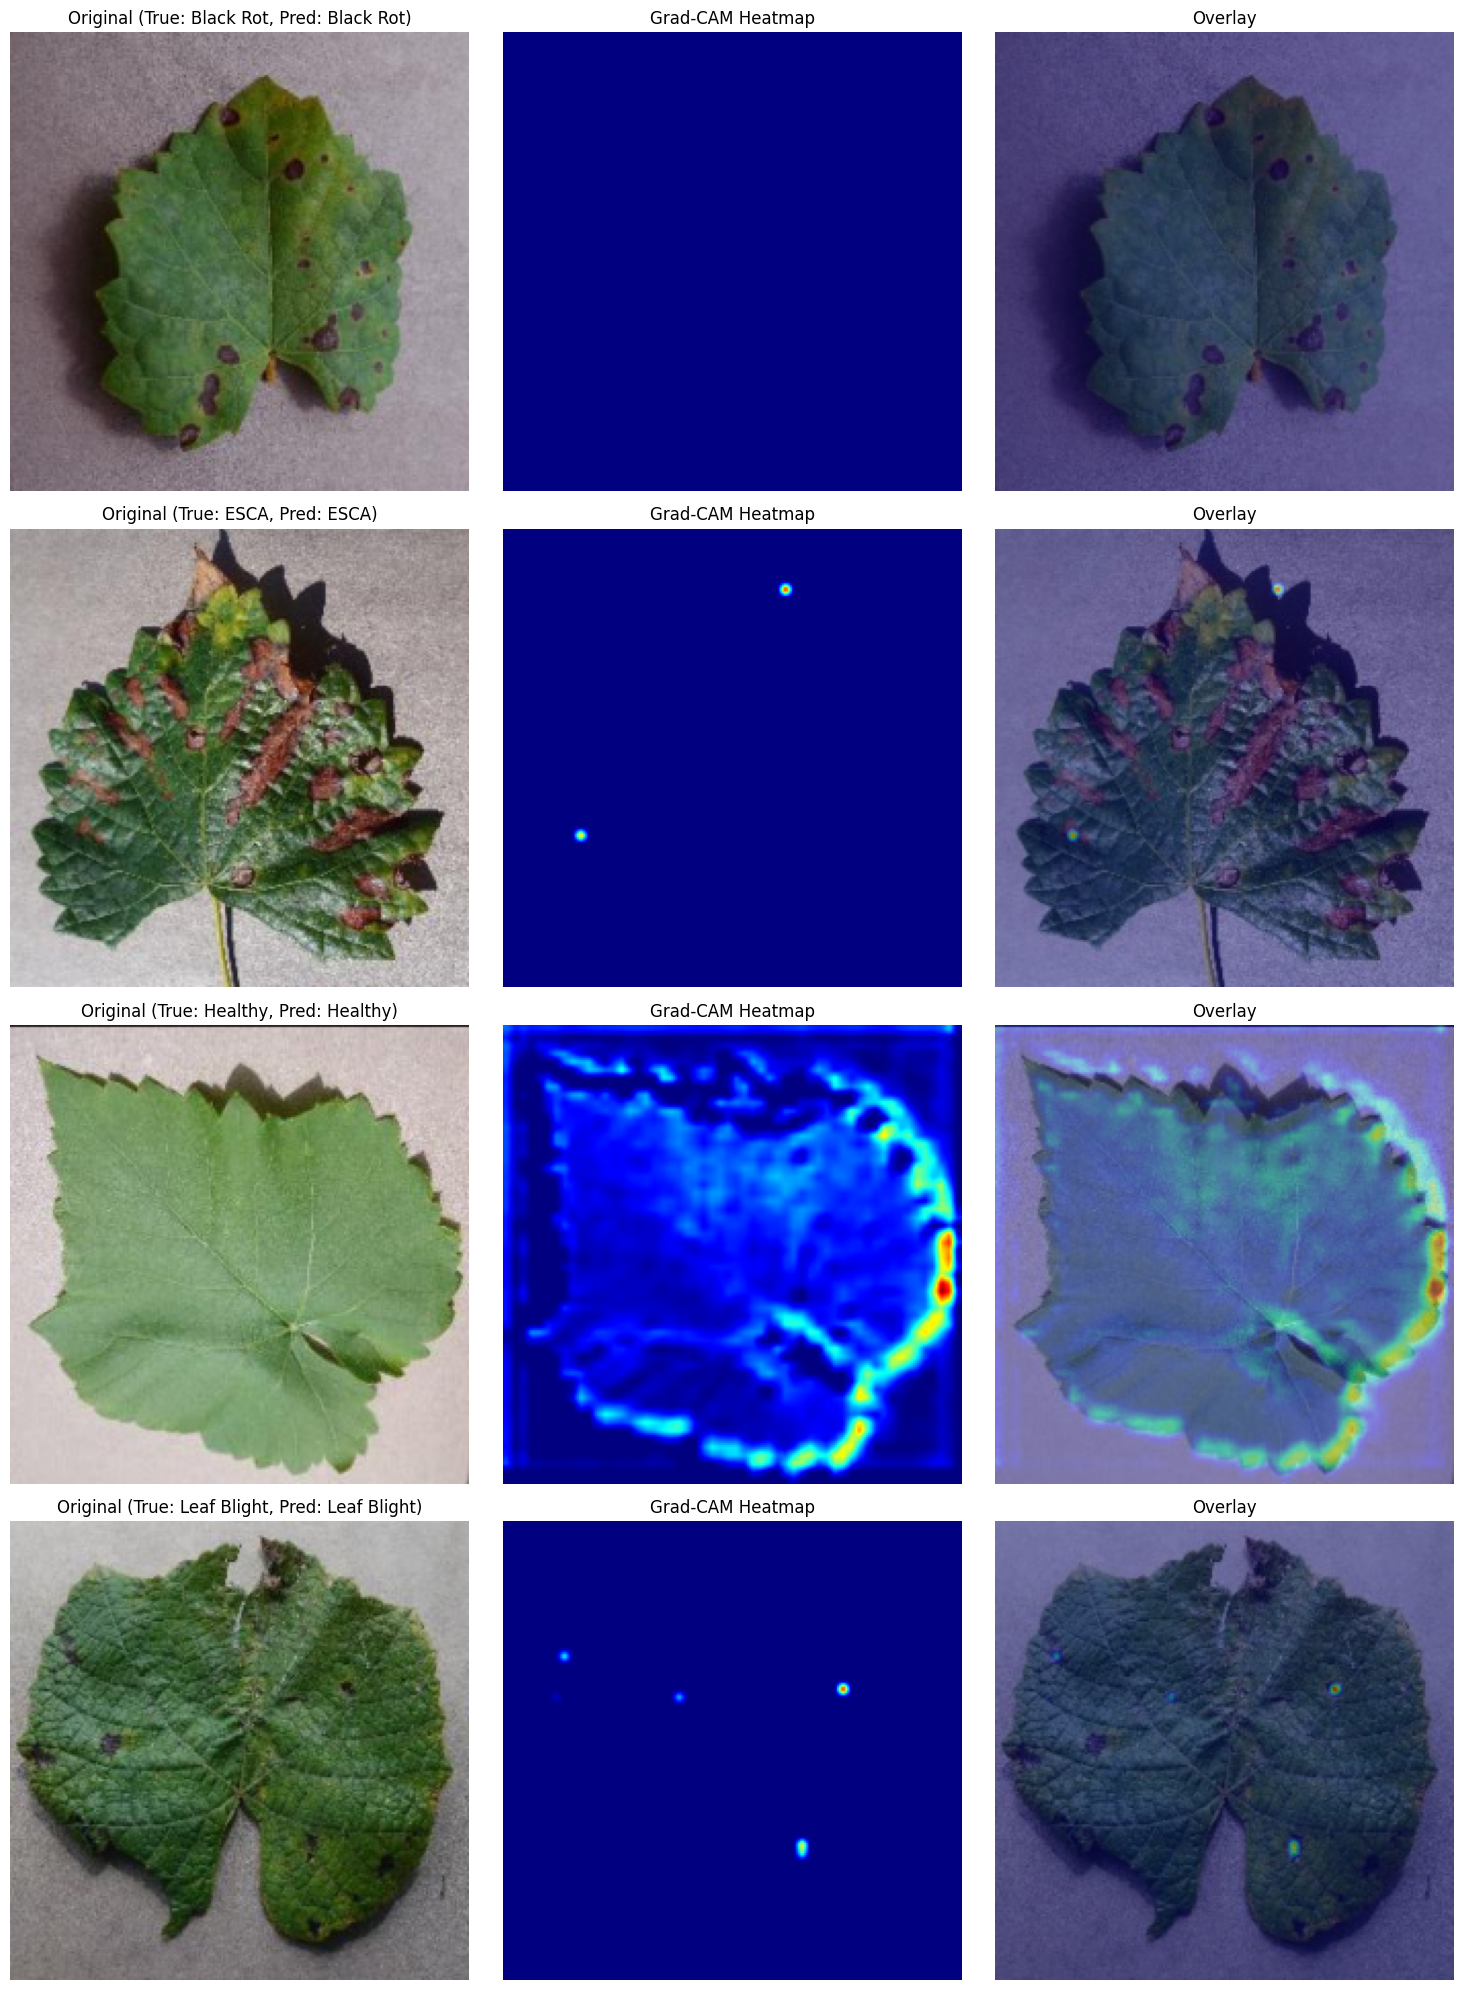

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCNNWithCustomPool(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

def train_one_epoch(loader):
    model.train()
    total_loss, total_correct = 0.0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

def validate(loader):
    model.eval()
    total_loss, total_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

train_accs, val_accs = [], []
train_losses, val_losses = [], []
max_epochs = 15

for epoch in range(1, max_epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    val_loss, val_acc = validate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f'Epoch {epoch:02d}/{max_epochs} | '
          f'Train: loss={train_loss:.4f}, acc={train_acc:.4f} | '
          f'Val: loss={val_loss:.4f}, acc={val_acc:.4f}')

torch.save(model.state_dict(), 'CustomCNN_Custompool_final.pth')

epochs = range(1, max_epochs + 1)
plt.figure()
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Custom CNN Accuracy over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Custom CNN Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

model.load_state_dict(torch.load('CustomCNN_Custompool_final.pth', map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

test_acc = np.mean(np.array(all_preds) == np.array(all_labels))
print(f'Test Accuracy: {test_acc:.4f}')

cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:\n', cm)
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=test_dataset.classes))

# Visualize Grad-CAM for one image per class
visualize_gradcam(model, test_loader, classes=test_dataset.classes, num_classes=4, device=device)

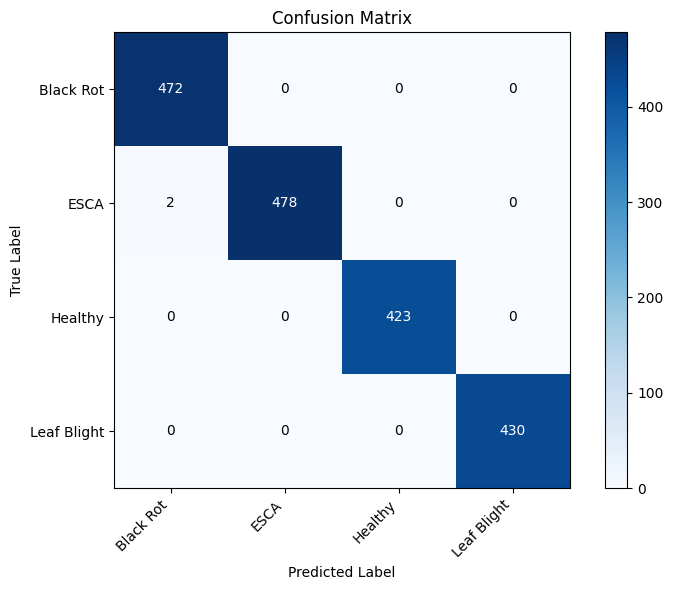

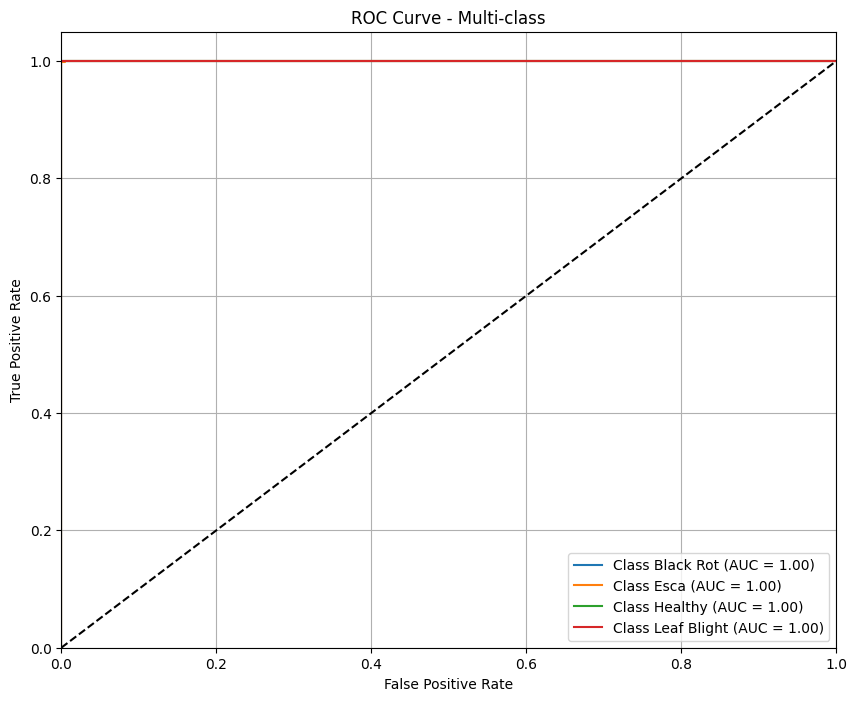

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
fig.colorbar(im, ax=ax)


ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticklabels(classes)


for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j],
                ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

def plot_roc_curve(model, dataloader, class_names, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # Binarize labels for multi-class ROC
    all_labels = label_binarize(all_labels, classes=list(range(len(class_names))))
    all_probs = np.array(all_probs)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    for i in range(len(class_names)):
        plt.plot(fpr[i], tpr[i], label=f'Class {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Multi-class')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

plot_roc_curve(model, test_loader, class_names=['Black Rot', 'Esca', 'Healthy', 'Leaf Blight'], device=device)